In [1]:
import sys
import os

# Example 1: Load and Plot Projection Maps

This notebook demonstrates how to load a TIGRESS-NCR simulation snapshot and
produce publication-quality figures of the face-on projection maps.

**Key steps**
1. Load the simulation object and discover available snapshots.
2. Load a single snapshot (projection maps + star-particle catalogue).
3. Plot emission measure (EM) and gas surface density (Σ_gas) maps with star-particle overlays.
4. Inspect the star-formation history and supernova log.

In [2]:
# use your pyathena installation path
sys.path.insert(0,'/home/changgoo/pyathena_master')
sys.path.insert(0,'../script/')

In [3]:
import pyathena as pa

In [4]:
from loadsim import load_sim, load_data, prj_to_xarray, get_cutout

## 1. Load the simulation object

`load_sim` resolves the data directory from the short paper model name,
registers all available projection snapshots, and pre-loads the history files.

In [5]:
model="R8-b1-Z1.0"
s=load_sim(model)

[LoadSim-INFO] basedir: /scratch/gpfs/changgoo/TIGRESS-NCR-projection-maps/notebook/../script/../data/R8-b1-Z1.0
[LoadSim-INFO] savdir: /scratch/gpfs/changgoo/TIGRESS-NCR-projection-maps/notebook/../script/../data/R8-b1-Z1.0
[LoadSim-INFO] load_method: xarray
[FindFiles-INFO] athinput: /scratch/gpfs/changgoo/TIGRESS-NCR-projection-maps/notebook/../script/../data/R8-b1-Z1.0/athinput.runtime
[FindFiles-INFO] athena_pp: False
[FindFiles-INFO] problem_id: R8_8pc_NCR
[FindFiles-WARNING] vtk files not found in /scratch/gpfs/changgoo/TIGRESS-NCR-projection-maps/notebook/../script/../data/R8-b1-Z1.0
[FindFiles-INFO] hst: /scratch/gpfs/changgoo/TIGRESS-NCR-projection-maps/notebook/../script/../data/R8-b1-Z1.0/hst/R8_8pc_NCR.hst
[FindFiles-INFO] sn: /scratch/gpfs/changgoo/TIGRESS-NCR-projection-maps/notebook/../script/../data/R8-b1-Z1.0/hst/R8_8pc_NCR.sn
[FindFiles-WARNING] zprof files not found in /scratch/gpfs/changgoo/TIGRESS-NCR-projection-maps/notebook/../script/../data/R8-b1-Z1.0
[FindFile

xi_CR0 not found. Use 2e-16.


In [6]:
# snapshot numbers
print(f"{len(s.nums)} snapshots are available from {s.nums[0]} to {s.nums[-1]}")

801 snapshots are available from 200 to 1000


## 2. Load a snapshot

`load_data` reads the projection pickle and star-particle VTK for a given
snapshot number. After this call, `s.prj`, `s.sp`, `s.sp_src`, and `s.time`
are all populated.

In [7]:
load_data(s,300)

## 3. Plot projection maps with star-particle overlays

Each panel shows a face-on (z-projected) map.  Star particles younger than
40 Myr are overlaid using `scatter_sp`; symbol area scales with cluster mass.

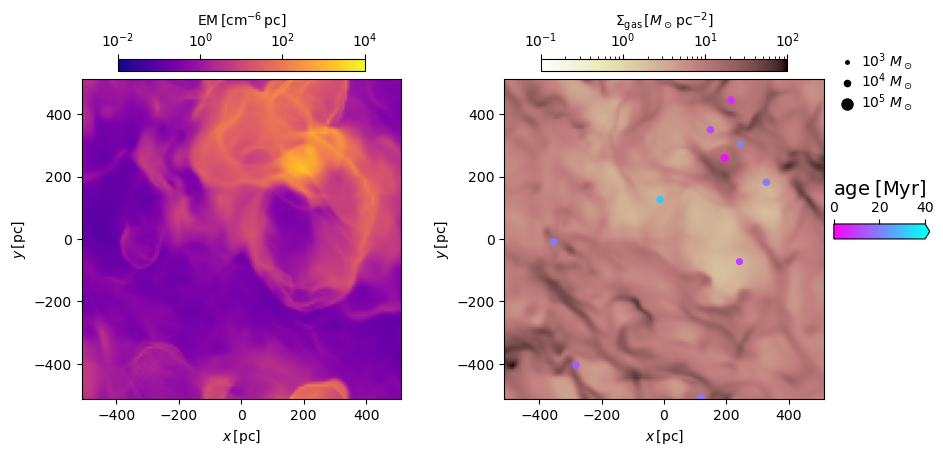

In [8]:
import matplotlib.pyplot as plt
# This is an example script to create a nice looking figure (something similar to what's in the paper)
fig, axs = plt.subplots(1,2, figsize=(10,5))
axes = dict()
plot_kwargs=dict()
plot_kwargs["Sigma_gas"] = dict(
    label=r"$\Sigma_{\rm gas}\,[M_\odot\,{\rm pc^{-2}}]$",
    norm=LogNorm(1.0e-1, 1.0e2),
    cmap=plt.cm.pink_r,
)
plot_kwargs["EM"] = dict(
    label=r"${\rm EM}\,[{\rm cm^{-6}\,pc}]$",
    norm=LogNorm(1.0e-2, 1.0e4),
    cmap=plt.cm.plasma,
)
for i, f in enumerate(["EM","Sigma_gas"]):
    ax = axs[i]
    axes[f] = ax
    plt.sca(ax)
    im = plt.imshow(
        s.prj["z"][f],
        extent=s.prj["extent"]["z"],
        origin="lower",
        **plot_kwargs[f]
    )
    cbar = plt.colorbar(
        im,
        pad=0.02,
        shrink=0.7,
        location="top",
        label=plot_kwargs[f]["label"])
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x\,[{\rm pc}]$")
    ax.set_ylabel(r"$y\,[{\rm pc}]$")

# There are some scripts I've wrote to ease particle plotting,
from pyathena.plt_tools.plt_starpar import scatter_sp, colorbar_sp, legend_sp

ax = axes["Sigma_gas"]
scatter_sp(s.sp, ax, "z", kpc=False, norm_factor=5, u=s.u, agemax=40)
legend_sp(ax, norm_factor=5, mass=[1.0e3, 1.0e4, 1.e5], location="right")
bbox = ax.get_position()
lx = bbox.x1 - bbox.x0
ly = bbox.y1 - bbox.y0
dx = lx*0.2
dy = ly * 0.1
bbox = [bbox.x1 + 0.01, bbox.y0 + 0.5*ly, 0.3*lx, 0.03]
colorbar_sp(fig, 40, bbox=bbox)


## 4. Star-formation history

The `.hst` file records domain-averaged quantities at every coarse time step.
`sfr40` is the surface density of star formation rate computed from star
clusters younger than 40 Myr and is already in physical units
(M☉ kpc⁻² yr⁻¹).  Time is in code units [pc/(km/s)]; multiply by `s.u.Myr`
to convert to Myr.

Text(0, 0.5, '$Sigma_{\\rm SFR}\\,[M_\\odot\\,{\\rm kpc^{-2}\\,yr^{-1}}]$')

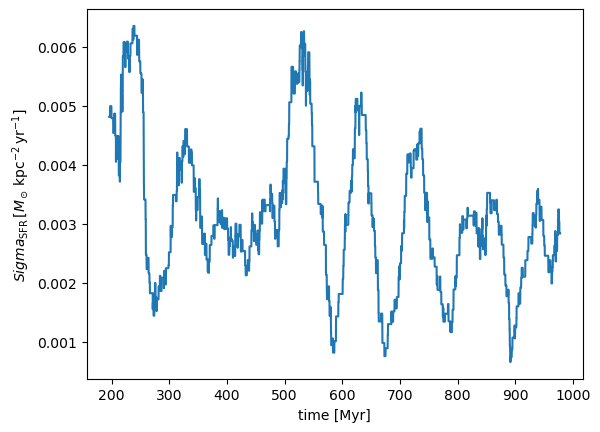

In [9]:
# read history output
# maybe useful to get the star formation rates
# time is in the code units [pc/(km/s)]: to convert Myr, multiply s.u.Myr
# sfr40 is the star formtation rate calculated using star clusters younger than 40 Myr
#       is already in the physical units [M_sun/kpc^2/yr]
plt.plot(s.hst["time"]*s.u.Myr,s.hst["sfr40"])
plt.xlabel("time [Myr]")
plt.ylabel(r"$Sigma_{\rm SFR}\,[M_\odot\,{\rm kpc^{-2}\,yr^{-1}}]$")

## 5. Supernova log

The `.sn` file records every supernova event.  Each row contains:
- `id` — parent star-particle ID
- `time` — explosion time (code units)
- `mass` — parent particle mass; **zero for runaway SNe** (ejected from cluster)
- `x1`, `x2`, `x3` — position of explosion (pc)

In [10]:
# supernova position exploded in time ~ (300,350)
sn_sel = s.sn.where((s.sn.time > 300) & (s.sn.time < 350)).dropna()
sn_sel_run = sn_sel.where(sn_sel.mass == 0).dropna()
sn_sel
# information important
# id: id of the star particle where the SN is originated from
# time: explosion time
# mass: mass of the original star particle. If zero, it means runaways
# x1,x2,x3: position of explosion

,id,time,age,mage,mass,x1,x2,x3,x1sn,x2sn,...,fm,fv2,fv4,d_den,d_M1,d_M2,d_M3,d_E,d_Ek,d_pr
4382,5062.0,300.0146,0.000399,18.914870,0.0,292.73490,-342.7507,-221.756000,292.73490,-342.7507,...,0.208531,0.603015,0.432950,0.564088,114.170800,-272.266900,81.639300,2836879.0,802836.6,6273.685
4383,5052.0,300.0276,7.211419,7.211419,274081.4,215.49790,444.8893,-87.143860,215.49790,444.8893,...,0.069246,0.601787,0.431184,0.564088,-9.775014,-39.610860,7.288126,2836879.0,802836.6,5970.913
4384,5081.0,300.1485,0.000589,12.579000,0.0,-36.20085,393.3257,110.964500,-36.20085,393.3257,...,0.353673,0.595405,0.421603,0.564088,103.034300,-142.731300,-12.438530,2836879.0,802836.6,7457.374
4385,4972.0,300.1485,15.777160,15.777160,241116.7,-281.45430,-402.6065,-14.849630,-281.45430,-402.6065,...,0.070666,0.601983,0.431381,0.564088,6.601385,48.659820,19.497030,2836879.0,802836.6,5345.891
4386,4949.0,300.1737,20.112820,20.112820,263062.9,328.21730,180.9785,-15.089370,328.21730,180.9785,...,0.076069,0.603026,0.432496,0.564088,38.483760,110.409300,59.826410,2836879.0,802836.6,4360.649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6400,5431.0,349.7425,26.040190,26.040190,279797.8,452.23660,-119.9018,92.096530,452.23660,-119.9018,...,0.034136,0.602031,0.431459,0.564088,11.266420,8.023753,5.983213,2836879.0,802836.6,5271.646
6401,5804.0,349.8031,4.811312,4.811312,273904.2,-242.96770,-148.1747,-64.707290,-242.96770,-148.1747,...,0.060301,0.596512,0.423612,0.564088,15.828790,11.926730,15.789040,2836879.0,802836.6,4101.952
6402,5635.0,349.8796,15.816260,15.816260,245938.7,481.09230,214.0300,-2.502058,481.09230,214.0300,...,0.046391,0.600267,0.428949,0.564088,-15.446700,27.176670,-15.367720,2836879.0,802836.6,4885.023
6403,5747.0,349.8816,0.000115,38.516720,0.0,200.22210,-105.6010,8.501942,200.22210,-105.6010,...,0.475966,0.610708,0.443484,0.564088,-130.863500,-414.849000,23.758470,2836879.0,802836.6,8201.268


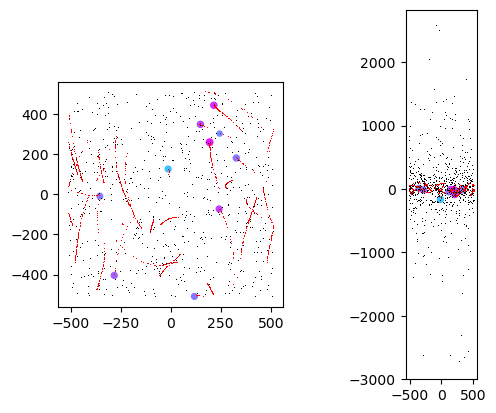

In [11]:
ax = plt.subplot(121)
plt.plot(sn_sel["x1"],sn_sel["x2"],',r')
plt.plot(sn_sel_run["x1"],sn_sel_run["x2"],',k')
scatter_sp(s.sp, ax, "z", kpc=False, norm_factor=5, u=s.u, agemax=40)
ax.set_aspect("equal")
ax = plt.subplot(122)
plt.plot(sn_sel["x1"],sn_sel["x3"],',r')
plt.plot(sn_sel_run["x1"],sn_sel_run["x3"],',k')
scatter_sp(s.sp, ax, "y", kpc=False, norm_factor=5, u=s.u, agemax=40)
ax.set_aspect("equal")